In [1]:
import sys
sys.path.append('/home/mark.bishop/Documents/Kea')
import kea
from kea.simulator import mff
from kea.statistics.statfunc import statfunc_numba, mpi_acf
from kea.utils import plotting
import numpy as np

NO MPI


In [2]:
N = 100_000
D = 1
kk = mff.make_grid(N, D)
field = mff.make_mff(kk[1], 5., 2./3., 40.)

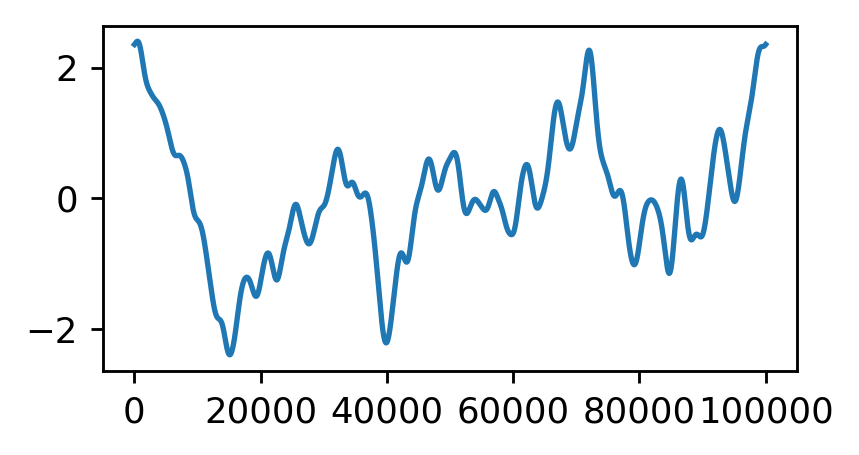

In [3]:
import matplotlib.pyplot as plt
# plotting.modify_rc()
# plotting.modify_rc()

fig, ax = plt.subplots(1, 1, figsize=(3.5, 1.75), dpi=256)
ax.plot(field)

In [13]:
# lags = np.zeros((N//2,1), dtype=np.int64)
# lags[:,0] = np.arange(0, N//2, dtype=np.int64)
mpi_lags = mpi_acf.get_all_lagvecs(tuple([N//2 for _ in range(D)]))
sf = statfunc_numba.process_lags(field, mpi_lags, 1)[:,0]
print(np.shape(sf))

(50000,)


In [8]:
mpi_lags = mpi_acf.get_all_lagvecs(tuple([N//2 for _ in range(D)]))
sf_naive = mpi_acf.process_lags(field, mpi_lags)

In [14]:
print(np.shape(sf_naive), np.shape(sf))

(50000,) (50000,)


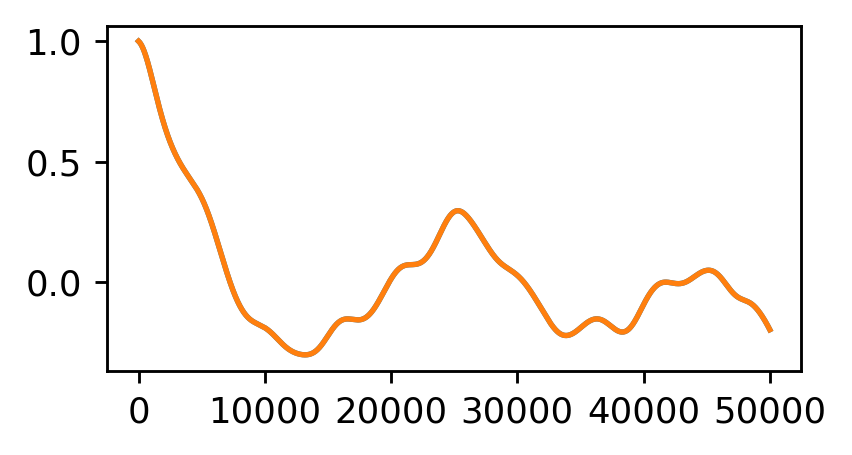

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(3.5, 1.75), dpi=256)
ax.plot(mpi_lags, sf)
ax.plot(mpi_lags, sf_naive)

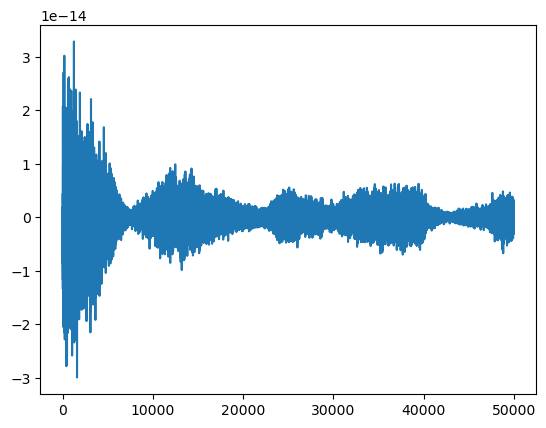

In [16]:
plt.plot(sf_naive - sf)

In [17]:
np.allclose(sf_naive, sf)

True